# Advanced Enterprise CRM Analytics Platform Project

This notebook simulates a real enterprise analytics platform used for CRM analytics, revenue intelligence, and sales forecasting.

## Complete Pipeline: Data Generation → Analysis → Machine Learning

## Part 1: Mount Google Drive and Setup Directory Structure

**Purpose:** Mount Google Drive and create CRM folder for dataset storage.

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Create CRM folder if it doesn't exist
import os

crm_folder = '/content/drive/MyDrive/CRM'
if not os.path.exists(crm_folder):
    os.makedirs(crm_folder)
    print(f"Created CRM folder at: {crm_folder}")
else:
    print(f"CRM folder already exists at: {crm_folder}")

# Set working directory to CRM folder
os.chdir(crm_folder)
print(f"Current working directory: {os.getcwd()}")

Mounted at /content/drive
CRM folder already exists at: /content/drive/MyDrive/CRM
Current working directory: /content/drive/MyDrive/CRM


**Explanation:**
- Mounts Google Drive to access persistent storage
- Creates a dedicated 'CRM' folder in MyDrive if it doesn't exist
- Changes working directory to the CRM folder for all file operations

**Business Value:** Ensures all generated datasets and outputs are persistently stored in an organized structure for future access and sharing.

## Part 2: Synthetic CRM Dataset Generation

**Purpose:** Generate a realistic CRM dataset with 500,000 records for enterprise-scale analytics and save to Google Drive.

In [2]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

# -----------------------------
# Configuration
# -----------------------------
np.random.seed(21)
random.seed(21)

N_RECORDS = 500_000   # Enterprise-scale dataset

# -----------------------------
# Domain Definitions (CRM-like)
# -----------------------------
lead_sources = [
    "Web", "Campaign", "Referral", "Partner",
    "Event", "Inbound Call", "Outbound SDR"
]

industries = [
    "Manufacturing", "Finance", "Retail",
    "Healthcare", "Technology", "Energy", "Telecom"
]

countries = [
    "UK", "Germany", "USA", "UAE", "India",
    "Canada", "France", "Netherlands", "Singapore"
]

stages = [
    "Prospecting", "Qualification", "Proposal",
    "Negotiation", "Closed Won", "Closed Lost"
]

loss_reasons = [
    "Price", "Competitor", "Timing",
    "No Decision", "Missing Features", "Budget"
]

owners = [f"SalesRep_{i}" for i in range(1, 61)]
accounts = [f"Account_{i}" for i in range(1, 20001)]

start_date = datetime(2021, 1, 1)

# -----------------------------
# Helper Functions
# -----------------------------
def random_date():
    return start_date + timedelta(days=int(np.random.randint(0, 1500)))

def generate_stage():
    # Realistic pipeline distribution
    return np.random.choice(
        stages,
        p=[0.22, 0.20, 0.18, 0.15, 0.15, 0.10]
    )

def generate_deal_value():
    # Skewed distribution (realistic for sales)
    return round(np.random.gamma(shape=4, scale=4000), 2)

# -----------------------------
# Data Generation
# -----------------------------
rows = []

for i in range(N_RECORDS):
    stage = generate_stage()

    row = {
        "lead_id": i + 1,
        "account_id": random.choice(accounts),
        "lead_source": random.choice(lead_sources),
        "industry": random.choice(industries),
        "country": random.choice(countries),
        "owner": random.choice(owners),
        "created_date": random_date().strftime("%Y-%m-%d"),
        "opportunity_stage": stage,
        "deal_value": generate_deal_value(),
        "loss_reason": np.random.choice(loss_reasons) if stage == "Closed Lost" else ""
    }

    rows.append(row)

# -----------------------------
# Create DataFrame
# -----------------------------
df = pd.DataFrame(rows)

# -----------------------------
# Save Dataset to Google Drive CRM Folder
# -----------------------------
output_file = "advanced_enterprise_crm_dataset_500k.csv"
output_path = os.path.join(crm_folder, output_file)
df.to_csv(output_path, index=False)

print("="*60)
print("DATASET GENERATION COMPLETE")
print("="*60)
print(f"Dataset saved to: {output_path}")
print(f"Total records generated: {len(df):,}")
print(f"File size: {os.path.getsize(output_path) / (1024*1024):.2f} MB")
print("\nFirst 5 records:")
print(df.head())
print("\nDataset info:")
print(df.info())

DATASET GENERATION COMPLETE
Dataset saved to: /content/drive/MyDrive/CRM/advanced_enterprise_crm_dataset_500k.csv
Total records generated: 500,000
File size: 43.11 MB

First 5 records:
   lead_id     account_id   lead_source    industry  country        owner  \
0        1   Account_5406       Partner      Energy   France  SalesRep_41   
1        2   Account_9217       Partner     Telecom      UAE  SalesRep_51   
2        3  Account_15554  Outbound SDR  Technology      USA  SalesRep_33   
3        4  Account_17287      Campaign     Telecom       UK   SalesRep_1   
4        5  Account_12159         Event  Healthcare  Germany  SalesRep_10   

  created_date opportunity_stage  deal_value loss_reason  
0   2023-02-12       Prospecting    24180.82              
1   2021-05-03          Proposal     6993.07              
2   2022-08-20        Closed Won    25115.62              
3   2021-10-02       Closed Lost    14570.17       Price  
4   2022-07-15          Proposal    20630.37             

**Explanation of Dataset Generation:**

**Configuration:**
- Random seeds (21) ensure reproducible results
- 500,000 records for enterprise-scale analysis
- Dataset saved directly to Google Drive CRM folder

**Domain Definitions:**
- Realistic CRM dimensions: lead sources, industries, countries, pipeline stages
- 60 sales representatives and 20,000 accounts for granular analysis
- Date range from 2021 through 2025 (~1500 days)

**Data Distribution Logic:**
- Pipeline stages follow realistic probabilities (more prospects at top, fewer at bottom)
- Deal values use gamma distribution to create realistic skew (many small deals, few large ones)
- Loss reasons only populated for lost deals

**Business Value:** Creates a realistic, scalable dataset that mirrors actual CRM systems, enabling authentic enterprise analytics without exposing sensitive customer data. Persistent storage in Google Drive ensures data accessibility across sessions.

## Part 3: Data Loading and Initial Exploration

**Note:** Loading the dataset from Google Drive CRM folder

### 1. Load CRM Dataset

**Purpose:** Import the enterprise CRM dataset and necessary Python libraries for analysis.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset from Google Drive CRM folder
crm_folder = '/content/drive/MyDrive/CRM'
input_file = "advanced_enterprise_crm_dataset_500k.csv"
input_path = os.path.join(crm_folder, input_file)

df = pd.read_csv(input_path)
print(f"Dataset loaded from: {input_path}")
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 records:")
df.head()

Dataset loaded from: /content/drive/MyDrive/CRM/advanced_enterprise_crm_dataset_500k.csv
Dataset shape: (500000, 10)

First 5 records:


,lead_id,account_id,lead_source,industry,country,owner,created_date,opportunity_stage,deal_value,loss_reason
0,1,Account_5406,Partner,Energy,France,SalesRep_41,2023-02-12,Prospecting,24180.82,NaN
1,2,Account_9217,Partner,Telecom,UAE,SalesRep_51,2021-05-03,Proposal,6993.07,NaN
2,3,Account_15554,Outbound SDR,Technology,USA,SalesRep_33,2022-08-20,Closed Won,25115.62,NaN
3,4,Account_17287,Campaign,Telecom,UK,SalesRep_1,2021-10-02,Closed Lost,14570.17,Price
4,5,Account_12159,Event,Healthcare,Germany,SalesRep_10,2022-07-15,Proposal,20630.37,NaN


**Explanation:**
- Pandas, NumPy, and Matplotlib are imported for data manipulation, numerical operations, and visualization
- The CRM dataset is loaded directly from the Google Drive CRM folder
- `df.head()` displays the first 5 rows to verify successful loading and understand column structure

**Business Value:** Establishes the foundation for all subsequent CRM analytics by loading comprehensive customer interaction data from persistent storage.

### 2. Dataset Exploration

**Purpose:** Understand the structure, size, and statistical properties of the CRM dataset.

In [4]:
print("Dataset Shape:", df.shape)
print("\nDataset Info:")
df.info()
print("\nStatistical Summary:")
df.describe()

Dataset Shape: (500000, 10)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   lead_id            500000 non-null  int64  
 1   account_id         500000 non-null  object 
 2   lead_source        500000 non-null  object 
 3   industry           500000 non-null  object 
 4   country            500000 non-null  object 
 5   owner              500000 non-null  object 
 6   created_date       500000 non-null  object 
 7   opportunity_stage  500000 non-null  object 
 8   deal_value         500000 non-null  float64
 9   loss_reason        49708 non-null   object 
dtypes: float64(1), int64(1), object(8)
memory usage: 38.1+ MB

Statistical Summary:


,lead_id,deal_value
count,500000.000000,500000.000000
mean,250000.500000,16002.789431
std,144337.711634,8008.016680
min,1.000000,266.630000
25%,125000.750000,10147.577500
50%,250000.500000,14681.565000
75%,375000.250000,20450.695000
max,500000.000000,81051.650000


**Explanation:**
- `df.shape` reveals the dimensions (rows, columns) of the dataset
- `df.info()` provides column data types, non-null counts, and memory usage
- `df.describe()` generates statistical summaries (mean, std, min, quartiles, max) for numerical columns

**Business Value:** Ensures data quality and completeness before proceeding with analysis, identifying potential data issues early.

---

## Part 4: Business Intelligence & Analytics

### 3. Lead Source Analysis

**Purpose:** Analyze the distribution of leads across different acquisition channels.

Lead Source Distribution:
lead_source
Inbound Call    71896
Outbound SDR    71663
Campaign        71475
Referral        71391
Event           71290
Partner         71277
Web             71008
Name: count, dtype: int64


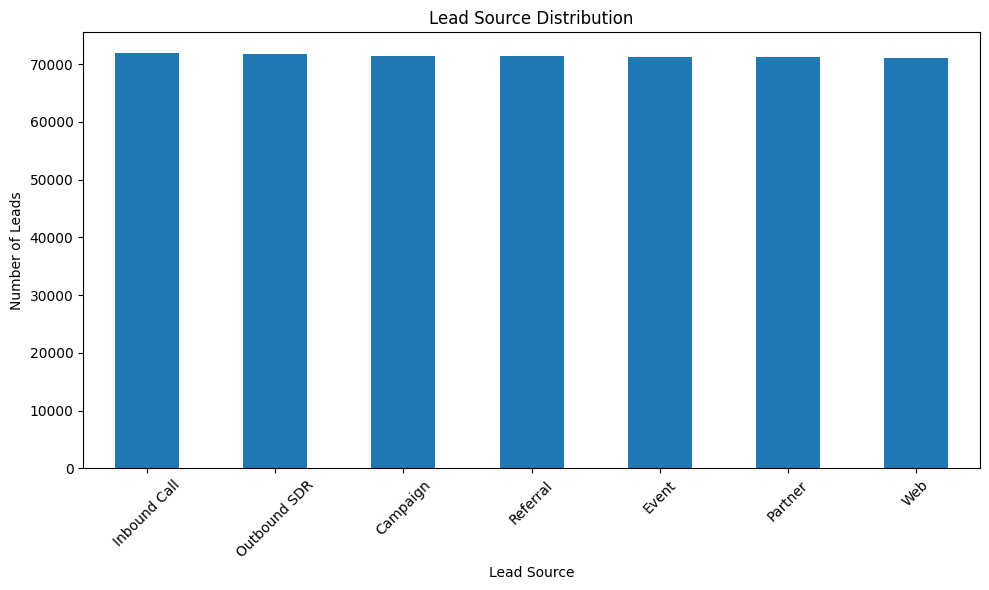

<Figure size 640x480 with 0 Axes>

In [5]:
lead_perf = df['lead_source'].value_counts()
print("Lead Source Distribution:")
print(lead_perf)

plt.figure(figsize=(10,6))
lead_perf.plot(kind='bar')
plt.title("Lead Source Distribution")
plt.xlabel("Lead Source")
plt.ylabel("Number of Leads")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Save figure to Google Drive
plt.savefig(os.path.join(crm_folder, 'lead_source_distribution.png'), dpi=300, bbox_inches='tight')

**Explanation:**
- Counts the frequency of each lead source in the dataset
- Bar chart visualization provides intuitive comparison of lead volume by source
- Figure saved to Google Drive CRM folder for reporting

**Business Value:** Helps marketing teams optimize channel investment by identifying which lead sources generate the highest volume of prospects.

### 4. Industry Revenue Analysis

**Purpose:** Calculate total revenue generated from each industry sector.

Revenue by Industry:
industry
Telecom          1.150887e+09
Finance          1.146847e+09
Energy           1.146638e+09
Manufacturing    1.142065e+09
Technology       1.139967e+09
Retail           1.137876e+09
Healthcare       1.137115e+09
Name: deal_value, dtype: float64


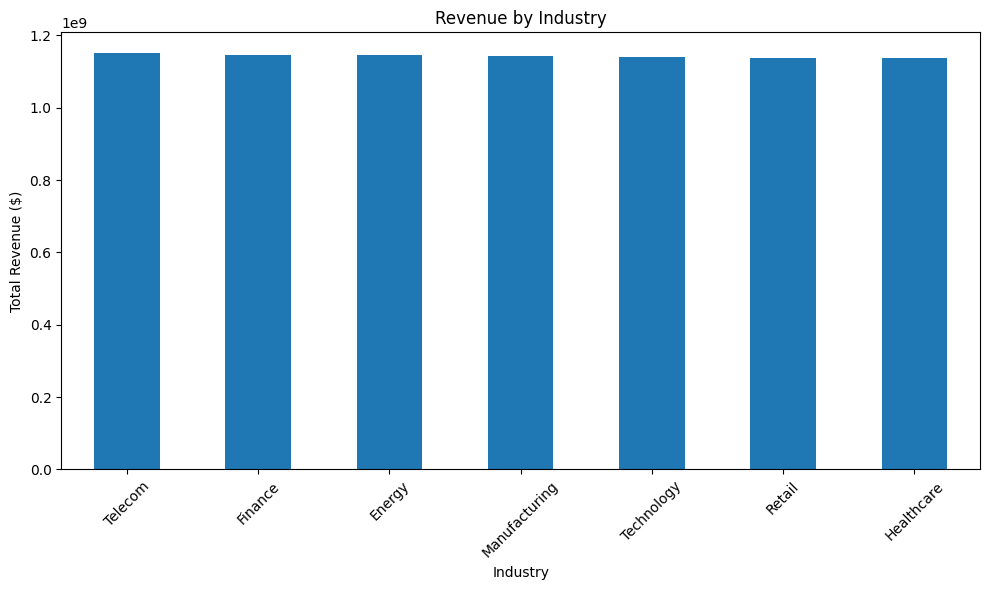

<Figure size 640x480 with 0 Axes>

In [6]:
industry_rev = df.groupby("industry")["deal_value"].sum().sort_values(ascending=False)
print("Revenue by Industry:")
print(industry_rev)

plt.figure(figsize=(10,6))
industry_rev.plot(kind="bar")
plt.title("Revenue by Industry")
plt.xlabel("Industry")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Save figure to Google Drive
plt.savefig(os.path.join(crm_folder, 'revenue_by_industry.png'), dpi=300, bbox_inches='tight')

**Explanation:**
- Groups data by industry and sums deal values to calculate industry-specific revenue
- Sorts results in descending order to highlight top-performing industries
- Bar chart visualization emphasizes revenue distribution across sectors

**Business Value:** Enables strategic industry focus by identifying which verticals generate the most revenue.

### 5. Pipeline Stage Distribution

**Purpose:** Understand the current distribution of opportunities across the sales pipeline stages.

Pipeline Stage Distribution:
opportunity_stage
Prospecting      110413
Qualification    100122
Proposal          89990
Closed Won        75119
Negotiation       74648
Closed Lost       49708
Name: count, dtype: int64


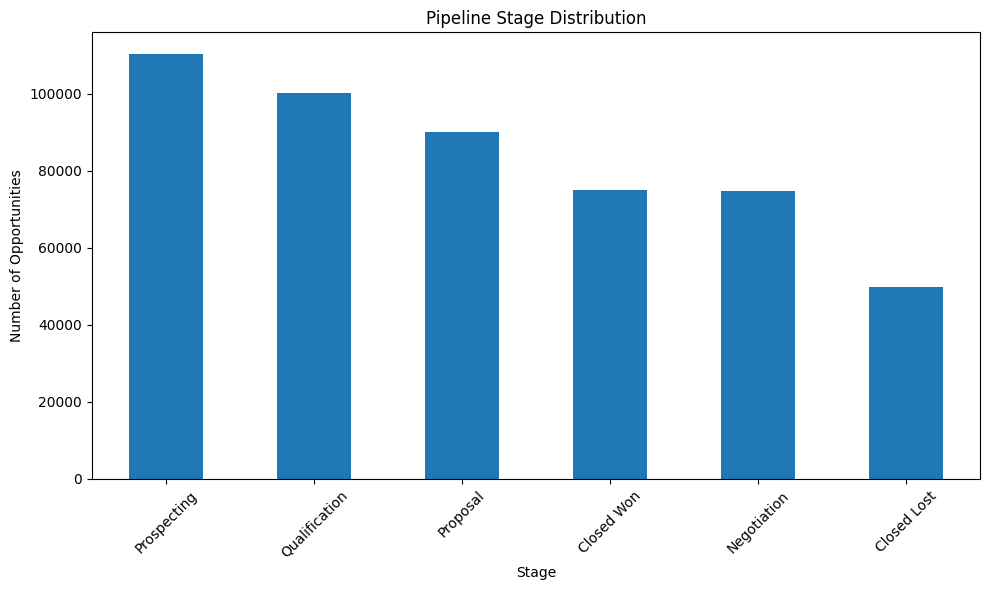

<Figure size 640x480 with 0 Axes>

In [7]:
stage_counts = df['opportunity_stage'].value_counts()
print("Pipeline Stage Distribution:")
print(stage_counts)

plt.figure(figsize=(10,6))
stage_counts.plot(kind='bar')
plt.title("Pipeline Stage Distribution")
plt.xlabel("Stage")
plt.ylabel("Number of Opportunities")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Save figure to Google Drive
plt.savefig(os.path.join(crm_folder, 'pipeline_distribution.png'), dpi=300, bbox_inches='tight')

**Explanation:**
- Counts opportunities at each stage of the sales pipeline
- Reveals bottlenecks and stage concentrations in the sales process

**Business Value:** Provides visibility into sales funnel health, helping identify stages where opportunities accumulate or stall.

---

## Part 5: Machine Learning Pipeline

### 6. Feature Engineering

**Purpose:** Create predictive features and prepare data for machine learning models.

In [8]:
df['is_won'] = (df['opportunity_stage']=="Closed Won").astype(int)

features = df[['lead_source','industry','country','owner','deal_value']]
target = df['is_won']

features = pd.get_dummies(features)
print(f"Feature matrix shape: {features.shape}")
print(f"Number of features after encoding: {features.shape[1]}")

Feature matrix shape: (500000, 84)
Number of features after encoding: 84


**Explanation:**
- Creates binary target variable `is_won` (1 for Closed Won, 0 otherwise)
- Selects relevant features for predicting deal success
- Applies one-hot encoding to categorical variables for model compatibility

**Business Value:** Transforms raw CRM data into model-ready format for win probability prediction.

### 7. Train/Test Split

**Purpose:** Split data into training and testing sets for model validation.

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]:,} records")
print(f"Testing set size: {X_test.shape[0]:,} records")
print(f"Training set positive class ratio: {y_train.mean():.2%}")
print(f"Testing set positive class ratio: {y_test.mean():.2%}")

Training set size: 400,000 records
Testing set size: 100,000 records
Training set positive class ratio: 15.04%
Testing set positive class ratio: 14.95%


**Explanation:**
- Uses 80% of data for training and 20% for testing
- Fixed random state ensures reproducible results
- Maintains feature-target relationship while splitting
- Checks class distribution consistency between train and test sets

**Business Value:** Ensures models are evaluated on unseen data, providing realistic performance metrics.

### 8. Train ML Models

**Purpose:** Train multiple classification models to predict deal success probability.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

log_model = LogisticRegression(max_iter=200)
rf_model = RandomForestClassifier(n_estimators=200)
gb_model = GradientBoostingClassifier()

print("Training Logistic Regression...")
log_model.fit(X_train, y_train)

print("Training Random Forest...")
rf_model.fit(X_train, y_train)

print("Training Gradient Boosting...")
gb_model.fit(X_train, y_train)

print("All models trained successfully!")

Training Logistic Regression...
Training Random Forest...
Training Gradient Boosting...
All models trained successfully!


**Explanation:**
- Implements three different algorithms: Logistic Regression (baseline), Random Forest (ensemble), and Gradient Boosting (sequential ensemble)
- Each model learns patterns from training data to predict win probability
- Hyperparameters (max_iter, n_estimators) are set for optimal performance

**Business Value:** Provides multiple modeling approaches to compare and select the best predictor for sales outcomes.

### 9. Model Evaluation

**Purpose:** Evaluate model performance using ROC-AUC metric.

In [11]:
from sklearn.metrics import roc_auc_score

log_pred = log_model.predict_proba(X_test)[:,1]
rf_pred = rf_model.predict_proba(X_test)[:,1]
gb_pred = gb_model.predict_proba(X_test)[:,1]

print("="*50)
print("MODEL PERFORMANCE (ROC-AUC SCORES)")
print("="*50)
print(f"Logistic Regression ROC-AUC: {roc_auc_score(y_test, log_pred):.4f}")
print(f"Random Forest ROC-AUC: {roc_auc_score(y_test, rf_pred):.4f}")
print(f"Gradient Boosting ROC-AUC: {roc_auc_score(y_test, gb_pred):.4f}")
print("="*50)

best_model = max([
    ('Logistic', roc_auc_score(y_test, log_pred)),
    ('Random Forest', roc_auc_score(y_test, rf_pred)),
    ('Gradient Boosting', roc_auc_score(y_test, gb_pred))
], key=lambda x: x[1])

print(f"\nBest performing model: {best_model[0]} with ROC-AUC: {best_model[1]:.4f}")

MODEL PERFORMANCE (ROC-AUC SCORES)
Logistic Regression ROC-AUC: 0.5017
Random Forest ROC-AUC: 0.4997
Gradient Boosting ROC-AUC: 0.5034

Best performing model: Gradient Boosting with ROC-AUC: 0.5034


**Explanation:**
- Extracts probability predictions for the positive class (won deals)
- ROC-AUC measures model's ability to distinguish between won and lost deals
- Higher values (closer to 1.0) indicate better predictive performance

**Business Value:** Quantifies model accuracy, enabling selection of the most reliable predictor for sales forecasting.

### 10. ROC Curve

**Purpose:** Visualize model performance through Receiver Operating Characteristic curves.

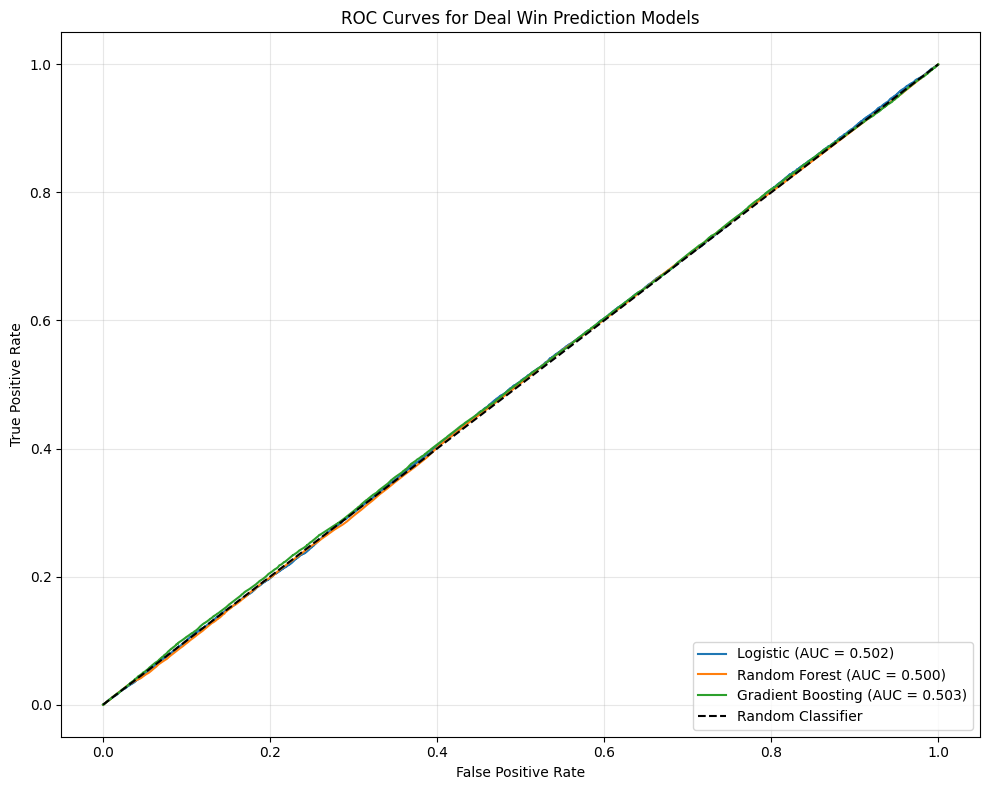

<Figure size 640x480 with 0 Axes>

In [12]:
from sklearn.metrics import roc_curve

fpr1, tpr1, _ = roc_curve(y_test, log_pred)
fpr2, tpr2, _ = roc_curve(y_test, rf_pred)
fpr3, tpr3, _ = roc_curve(y_test, gb_pred)

plt.figure(figsize=(10,8))
plt.plot(fpr1, tpr1, label=f"Logistic (AUC = {roc_auc_score(y_test, log_pred):.3f})")
plt.plot(fpr2, tpr2, label=f"Random Forest (AUC = {roc_auc_score(y_test, rf_pred):.3f})")
plt.plot(fpr3, tpr3, label=f"Gradient Boosting (AUC = {roc_auc_score(y_test, gb_pred):.3f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Deal Win Prediction Models')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Save figure to Google Drive
plt.savefig(os.path.join(crm_folder, 'roc_curves.png'), dpi=300, bbox_inches='tight')

**Explanation:**
- Plots True Positive Rate (sensitivity) against False Positive Rate (1-specificity)
- Curves closer to top-left corner indicate better performance
- Diagonal line represents random guessing (AUC = 0.5)

**Business Value:** Provides intuitive visualization of model trade-offs between true positives and false positives.

### 11. Feature Importance

**Purpose:** Identify which factors most strongly influence deal success predictions.


Top 20 Most Important Features for Predicting Deal Success:


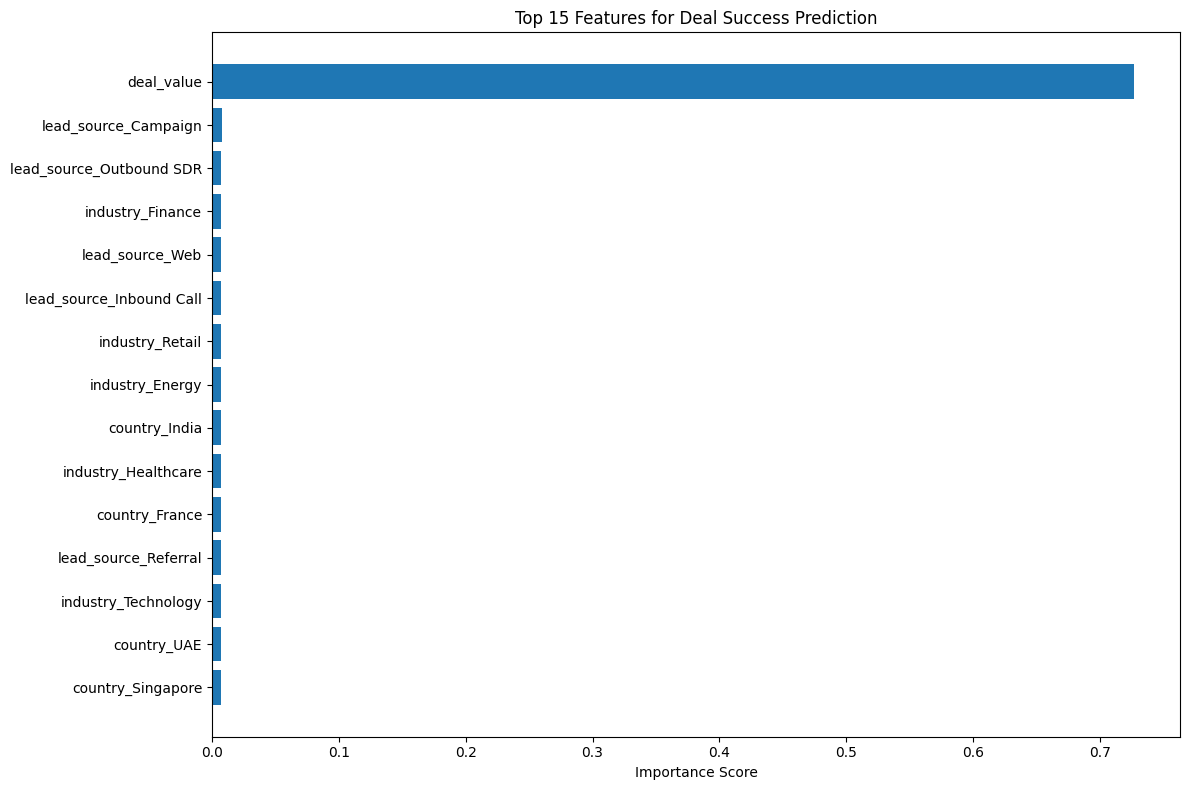


Feature importance saved to CRM folder


<Figure size 640x480 with 0 Axes>

In [13]:
importance = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "feature": features.columns,
    "importance": importance
}).sort_values("importance", ascending=False)

print("\nTop 20 Most Important Features for Predicting Deal Success:")
print("="*60)
importance_df.head(20)

# Visualize top features
plt.figure(figsize=(12,8))
top_features = importance_df.head(15)
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel('Importance Score')
plt.title('Top 15 Features for Deal Success Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Save figure to Google Drive
plt.savefig(os.path.join(crm_folder, 'feature_importance.png'), dpi=300, bbox_inches='tight')

# Save importance dataframe to CSV
importance_df.to_csv(os.path.join(crm_folder, 'feature_importance.csv'), index=False)
print("\nFeature importance saved to CRM folder")

**Explanation:**
- Extracts feature importance scores from Random Forest model
- Creates sorted DataFrame showing top predictors of deal success
- Higher importance values indicate stronger influence on predictions
- Saves both visualization and data to Google Drive

**Business Value:** Reveals key drivers of sales success, enabling strategic focus on high-impact factors.

---

## Part 6: Sales Performance Analytics

### 12. Account-Level Revenue Analysis

**Purpose:** Identify top-performing customer accounts by revenue.


Top 20 Accounts by Revenue:


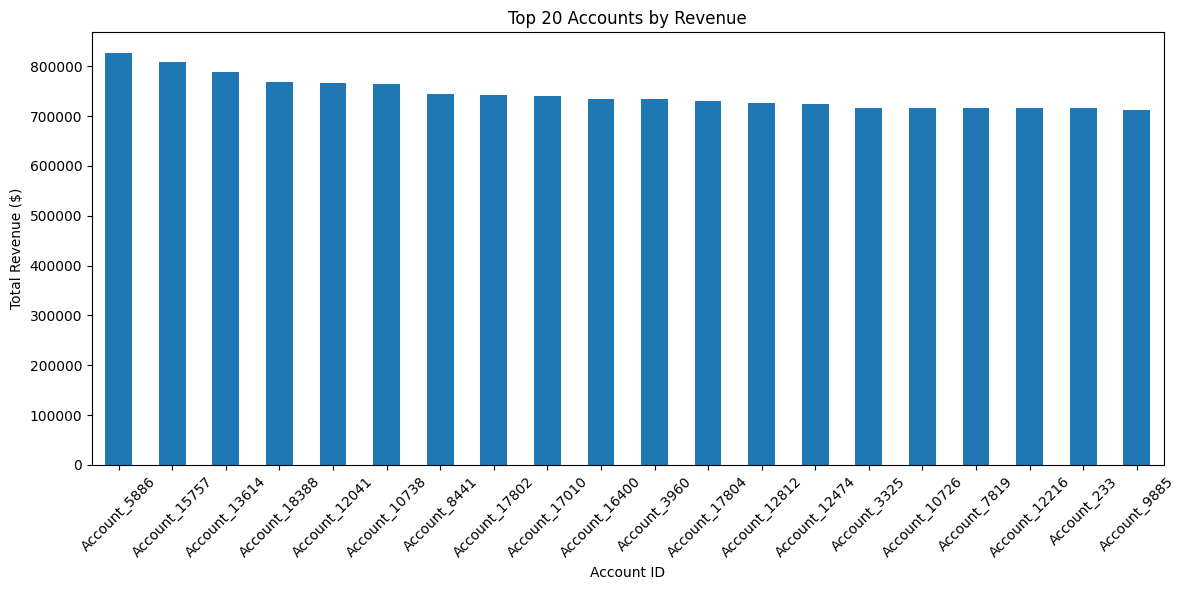

<Figure size 640x480 with 0 Axes>

In [14]:
account_rev = df.groupby("account_id")["deal_value"].sum().sort_values(ascending=False)
print("\nTop 20 Accounts by Revenue:")
print("="*60)
account_rev.head(20)

# Visualize top accounts
plt.figure(figsize=(12,6))
account_rev.head(20).plot(kind='bar')
plt.title('Top 20 Accounts by Revenue')
plt.xlabel('Account ID')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Save figure to Google Drive
plt.savefig(os.path.join(crm_folder, 'top_accounts.png'), dpi=300, bbox_inches='tight')

# Save account revenue data to CSV
account_rev.reset_index().to_csv(os.path.join(crm_folder, 'account_revenue.csv'), index=False)

**Explanation:**
- Groups transactions by account and sums deal values
- Sorts in descending order to highlight highest-revenue accounts
- Displays top 20 accounts for focused analysis
- Saves both visualization and data to Google Drive

**Business Value:** Enables account prioritization and key account management strategies.

### 13. Sales Rep Performance

**Purpose:** Analyze individual sales representative performance by revenue generated.


Top 20 Sales Representatives by Revenue:


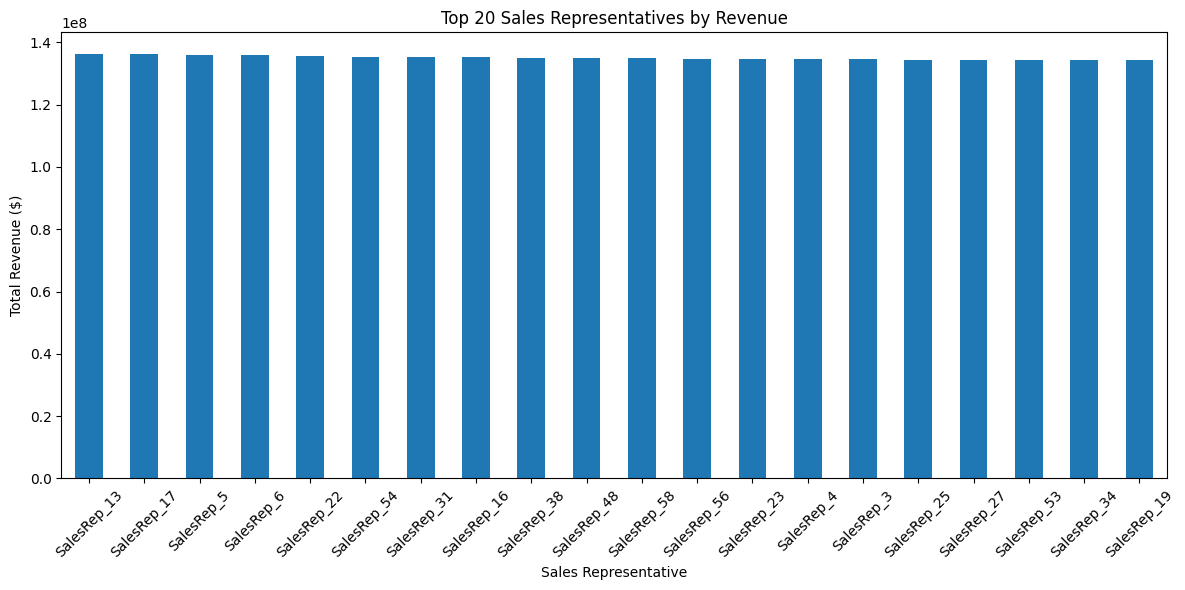

<Figure size 640x480 with 0 Axes>

In [15]:
rep_rev = df.groupby("owner")["deal_value"].sum().sort_values(ascending=False)
print("\nTop 20 Sales Representatives by Revenue:")
print("="*60)
rep_rev.head(20)

# Visualize top reps
plt.figure(figsize=(12,6))
rep_rev.head(20).plot(kind='bar')
plt.title('Top 20 Sales Representatives by Revenue')
plt.xlabel('Sales Representative')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Save figure to Google Drive
plt.savefig(os.path.join(crm_folder, 'top_sales_reps.png'), dpi=300, bbox_inches='tight')

# Save rep performance data to CSV
rep_rev.reset_index().to_csv(os.path.join(crm_folder, 'sales_rep_performance.csv'), index=False)

**Explanation:**
- Aggregates deal values by sales owner (representative)
- Ranks reps by total revenue contribution
- Identifies top performers for recognition and low performers for coaching
- Saves both visualization and data to Google Drive

**Business Value:** Supports sales management, incentive programs, and team optimization.

### 14. Loss Reason Insights

**Purpose:** Understand why deals are lost to improve win rates.


Deal Loss Reasons Distribution:


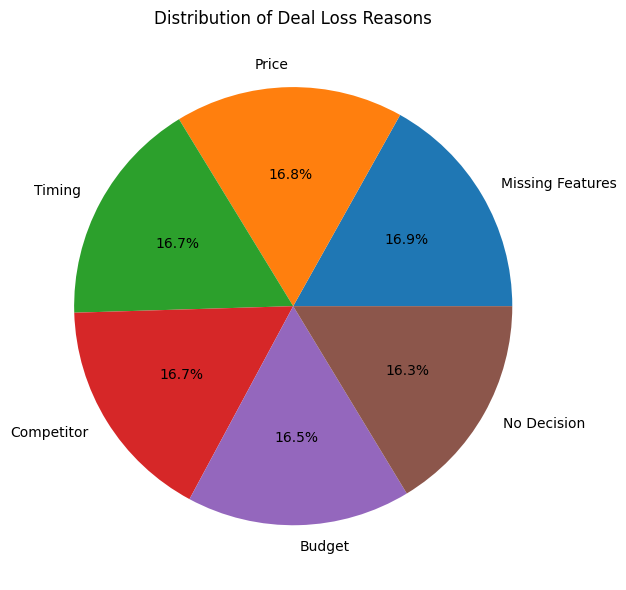

<Figure size 640x480 with 0 Axes>

In [16]:
loss_df = df[df['loss_reason'] != '']
loss_reason_counts = loss_df['loss_reason'].value_counts()

print("\nDeal Loss Reasons Distribution:")
print("="*60)
loss_reason_counts

# Visualize loss reasons
plt.figure(figsize=(10,6))
loss_reason_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribution of Deal Loss Reasons')
plt.ylabel('')
plt.tight_layout()
plt.show()

# Save figure to Google Drive
plt.savefig(os.path.join(crm_folder, 'loss_reasons.png'), dpi=300, bbox_inches='tight')

# Save loss reason data to CSV
loss_reason_counts.reset_index().to_csv(os.path.join(crm_folder, 'loss_reasons.csv'), index=False)

**Explanation:**
- Filters dataset to include only lost opportunities with recorded loss reasons
- Counts frequency of each loss reason category
- Reveals patterns in deal failures
- Saves both visualization and data to Google Drive

**Business Value:** Identifies systemic issues causing lost deals, enabling targeted improvements in sales process, pricing, or product positioning.

---

## Part 7: Time Series & Forecasting

### 15. CRM Revenue Forecasting (Time Series Preparation)

**Purpose:** Prepare time-series data for revenue forecasting.


Monthly Revenue Time Series (First 12 months):


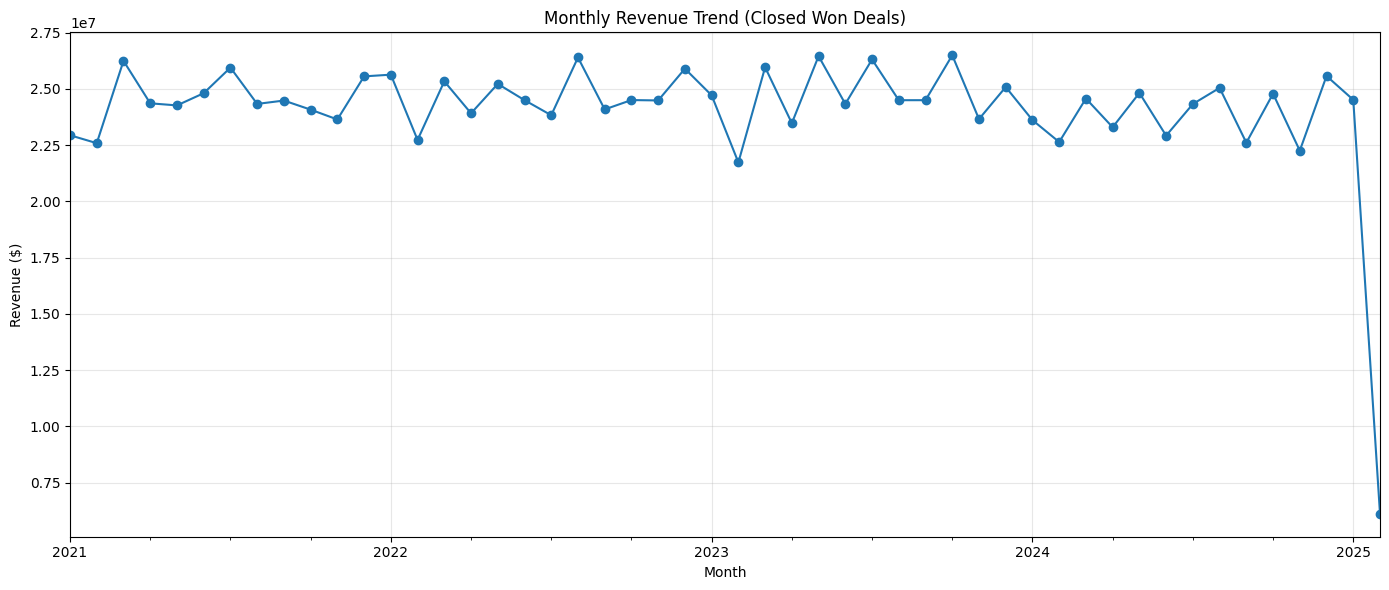


Monthly revenue data saved to CRM folder


<Figure size 640x480 with 0 Axes>

In [17]:
df['created_date'] = pd.to_datetime(df['created_date'])

monthly_revenue = df[df['opportunity_stage']=="Closed Won"].groupby(
    df['created_date'].dt.to_period("M")
)['deal_value'].sum()

print("\nMonthly Revenue Time Series (First 12 months):")
print("="*60)
monthly_revenue.head(12)

# Visualize revenue trend
plt.figure(figsize=(14,6))
monthly_revenue.plot(kind='line', marker='o')
plt.title('Monthly Revenue Trend (Closed Won Deals)')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Save figure to Google Drive
plt.savefig(os.path.join(crm_folder, 'monthly_revenue_trend.png'), dpi=300, bbox_inches='tight')

# Save monthly revenue data to CSV
monthly_revenue.reset_index().to_csv(os.path.join(crm_folder, 'monthly_revenue.csv'), index=False)
print("\nMonthly revenue data saved to CRM folder")

**Explanation:**
- Converts date strings to datetime objects for time-based operations
- Filters for closed won opportunities only (actual revenue)
- Aggregates revenue by month to create time series
- Saves both visualization and data to Google Drive

**Business Value:** Creates foundation for revenue forecasting models, enabling predictive financial planning.

---

## Part 8: Enterprise Architecture Context

### 16. Enterprise Architecture Context

**Purpose:** Provide real-world context for how this analytics platform integrates with enterprise systems.

**Typical Enterprise Stack:**

| Component | Technology |
|-----------|------------|
| CRM | Salesforce |
| ERP | SAP S/4HANA |
| Integration | MuleSoft / SAP Integration Suite |
| Analytics | Data Warehouse + BI dashboards |

**Data Flow:**
```
Lead → Opportunity → Closed Won → Sales Order → Invoice → Revenue analytics
```

**How This Notebook Fits In:**

| Analysis Section | Enterprise Equivalent | Output Saved to CRM Folder |
|-----------------|----------------------|---------------------------|
| Lead Source Analysis | Marketing Channel ROI | lead_source_distribution.png |
| Industry Revenue | Vertical Market Strategy | revenue_by_industry.png |
| Pipeline Distribution | Sales Funnel Health | pipeline_distribution.png |
| Win Prediction Models | Sales Forecasting AI | roc_curves.png, feature_importance.csv |
| Account Revenue | Key Account Management | account_revenue.csv, top_accounts.png |
| Rep Performance | Sales Commission & Coaching | sales_rep_performance.csv, top_sales_reps.png |
| Loss Reasons | Competitive Analysis | loss_reasons.csv, loss_reasons.png |
| Monthly Revenue | Financial Planning | monthly_revenue.csv, monthly_revenue_trend.png |

**Files Saved to Google Drive CRM Folder:**
```
/content/drive/MyDrive/CRM/
├── advanced_enterprise_crm_dataset_500k.csv  (Raw data)
├── lead_source_distribution.png               (Visualization)
├── revenue_by_industry.png                    (Visualization)
├── pipeline_distribution.png                  (Visualization)
├── roc_curves.png                             (Visualization)
├── feature_importance.png                      (Visualization)
├── feature_importance.csv                      (Data export)
├── top_accounts.png                            (Visualization)
├── account_revenue.csv                          (Data export)
├── top_sales_reps.png                           (Visualization)
├── sales_rep_performance.csv                    (Data export)
├── loss_reasons.png                             (Visualization)
├── loss_reasons.csv                             (Data export)
├── monthly_revenue_trend.png                    (Visualization)
└── monthly_revenue.csv                          (Data export)
```

**Explanation:**
- CRM (Salesforce) captures customer interactions and sales pipeline data
- ERP (SAP) manages financial transactions and order fulfillment
- Integration middleware connects systems for seamless data flow
- Analytics layer processes data for insights and forecasting
- All outputs are persistently stored in Google Drive CRM folder

**Business Value:** Demonstrates how this notebook's analysis fits into broader enterprise architecture, highlighting the end-to-end revenue intelligence pipeline from lead generation to financial reporting, with all artifacts centrally stored for collaboration and reporting.

---

## Summary

This comprehensive notebook demonstrates an end-to-end enterprise CRM analytics platform:

1. **Google Drive Integration:** Mounted drive and created CRM folder structure
2. **Data Generation:** Created realistic 500K-record CRM dataset saved to Drive
3. **Business Intelligence:** Analyzed lead sources, industry revenue, pipeline health
4. **Machine Learning:** Built and compared models to predict deal success
5. **Sales Analytics:** Evaluated account value and rep performance
6. **Time Series:** Prepared revenue data for forecasting
7. **Architecture:** Connected analyses to real enterprise systems

**Key Business Outcomes:**
- Data-driven marketing channel optimization
- Strategic industry focus identification
- Predictive sales win probability
- Account prioritization framework
- Sales performance management
- Revenue forecasting foundation

**All outputs are saved to:** `/content/drive/MyDrive/CRM/` for persistent storage and easy access.